In [ ]:
!pip install faker

import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns

fake = Faker()

In [ ]:
genders = ["Male", "Female"]
departments = ["CSE", "IT", "ECE"]
years = ["1st", "2nd", "3rd"]

data = []

for i in range(1, 251):
    student = {
        "Student_ID": i,
        "Name": fake.name(),
        "Gender": random.choice(genders),
        "Department": random.choice(departments),
        "Year": random.choice(years),
        "Maths": random.randint(0, 100),
        "Science": random.randint(0, 100),
        "English": random.randint(0, 100),
        "Attendance": random.randint(50, 100),
        "Internal_Marks": random.randint(0, 25)
    }
    data.append(student)

df = pd.DataFrame(data)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks
0,1,Mark Larson,Male,IT,1st,83,82,100,78,11
1,2,Lisa Freeman,Male,IT,2nd,37,82,32,61,9
2,3,Aaron Dean,Female,IT,1st,81,21,2,53,11
3,4,Ian Clarke,Male,CSE,2nd,37,59,99,97,15
4,5,Julia Lambert,Male,IT,3rd,21,18,2,76,14


In [ ]:
print("Missing Values:\n", df.isnull().sum())

df = df.drop_duplicates()

print("\nDataset Shape:", df.shape)

Missing Values:
 Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal_Marks    0
dtype: int64

Dataset Shape: (250, 10)


In [ ]:
df["Total"] = df["Maths"] + df["Science"] + df["English"]
df["Average"] = df["Total"] / 3

def grade(avg):
    if avg >= 80:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 40:
        return "C"
    else:
        return "Fail"

df["Grade"] = df["Average"].apply(grade)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total,Average,Grade
0,1,Mark Larson,Male,IT,1st,83,82,100,78,11,265,88.333333,A
1,2,Lisa Freeman,Male,IT,2nd,37,82,32,61,9,151,50.333333,C
2,3,Aaron Dean,Female,IT,1st,81,21,2,53,11,104,34.666667,Fail
3,4,Ian Clarke,Male,CSE,2nd,37,59,99,97,15,195,65.000000,B
4,5,Julia Lambert,Male,IT,3rd,21,18,2,76,14,41,13.666667,Fail


In [ ]:
df.describe()

,Student_ID,Maths,Science,English,Attendance,Internal_Marks,Total,Average
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,52.432000,49.436000,48.164000,75.540000,12.016000,150.032000,50.010667
std,72.312977,28.643168,29.101503,29.057641,13.776778,7.016314,51.970711,17.323570
min,1.000000,0.000000,0.000000,1.000000,50.000000,0.000000,31.000000,10.333333
25%,63.250000,27.250000,23.000000,23.000000,65.000000,7.000000,110.000000,36.666667
50%,125.500000,54.500000,50.000000,47.500000,76.000000,12.000000,149.500000,49.833333
75%,187.750000,77.750000,74.000000,73.500000,86.000000,17.000000,186.000000,62.000000
max,250.000000,100.000000,100.000000,100.000000,100.000000,25.000000,275.000000,91.666667


In [ ]:
top_students = df.sort_values(by="Average", ascending=False).head(5)
fail_students = df[df["Grade"] == "Fail"]

print("Top 5 Students:\n")
print(top_students)

print("\nFail Students:\n")
print(fail_students)

Top 5 Students:

     Student_ID               Name  Gender Department Year  Maths  Science  \
147         148      Antonio White  Female        ECE  1st     84       93   
0             1        Mark Larson    Male         IT  1st     83       82   
105         106        Anne Norman    Male        ECE  3rd     93       92   
32           33       Megan Nguyen  Female        CSE  1st     86       92   
39           40  Christopher Hayes  Female        ECE  3rd     76       86   

     English  Attendance  Internal_Marks  Total    Average Grade  
147       98          88               5    275  91.666667     A  
0        100          78              11    265  88.333333     A  
105       79          80              19    264  88.000000     A  
32        81          66               1    259  86.333333     A  
39        96          67              24    258  86.000000     A  

Fail Students:

     Student_ID                 Name  Gender Department Year  Maths  Science  \
2             3

In [ ]:
print("Department-wise Average:\n")
print(df.groupby("Department")["Average"].mean())

print("\nGender-wise Average:\n")
print(df.groupby("Gender")["Average"].mean())

print("\nYear-wise Average:\n")
print(df.groupby("Year")["Average"].mean())

Department-wise Average:

Department
CSE    50.835294
ECE    50.633745
IT     48.575397
Name: Average, dtype: float64

Gender-wise Average:

Gender
Female    49.606516
Male      50.470085
Name: Average, dtype: float64

Year-wise Average:

Year
1st    48.400000
2nd    50.068966
3rd    51.502008
Name: Average, dtype: float64


/tmp/ipykernel_415/1520536480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


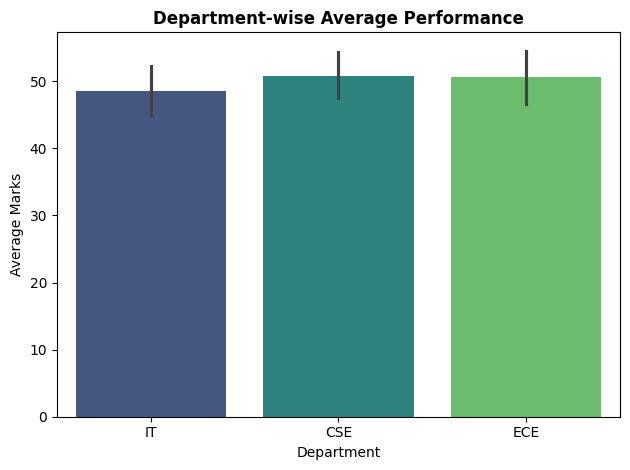

In [ ]:
plt.figure()

sns.barplot(
    x="Department",
    y="Average",
    data=df,
    palette="viridis"
)

plt.title("Department-wise Average Performance", weight='bold')
plt.xlabel("Department")
plt.ylabel("Average Marks")

plt.tight_layout()
plt.show()

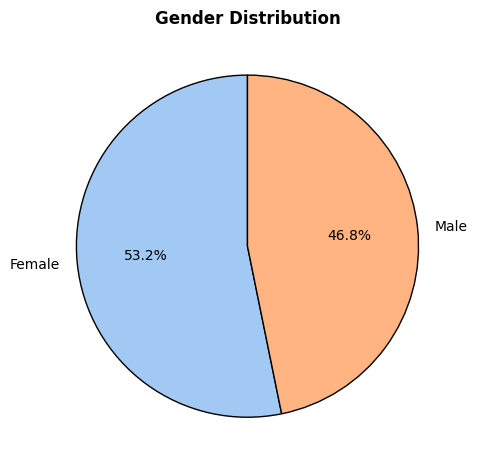

In [ ]:
plt.figure()

df["Gender"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
    startangle=90,
    wedgeprops={"edgecolor": "black"}
)

plt.title("Gender Distribution", weight='bold')
plt.ylabel("")

plt.tight_layout()
plt.show()

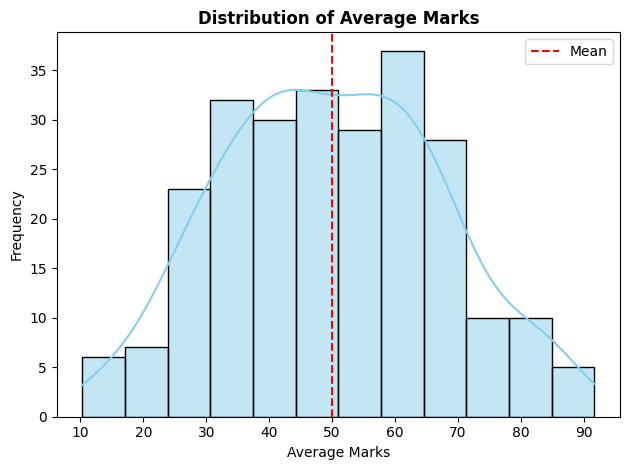

In [ ]:
plt.figure()

sns.histplot(df["Average"], bins=12, kde=True, color="skyblue")

plt.axvline(df["Average"].mean(), color='red', linestyle='--', label='Mean')

plt.title("Distribution of Average Marks", weight='bold')
plt.xlabel("Average Marks")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

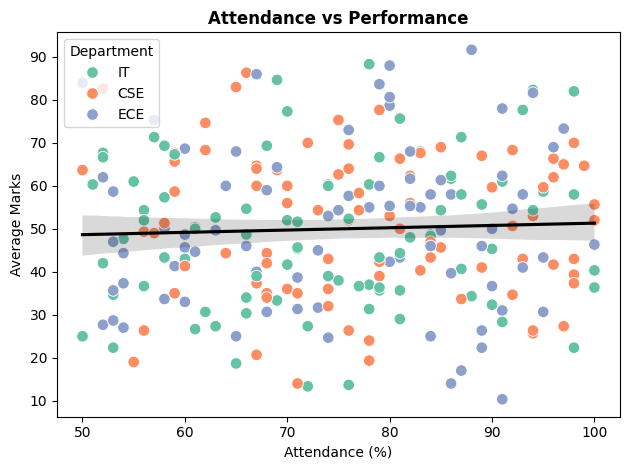

In [ ]:
plt.figure()

sns.scatterplot(
    x="Attendance",
    y="Average",
    data=df,
    hue="Department",
    palette="Set2",
    s=70
)

sns.regplot(
    x="Attendance",
    y="Average",
    data=df,
    scatter=False,
    color="black"
)

plt.title("Attendance vs Performance", weight='bold')
plt.xlabel("Attendance (%)")
plt.ylabel("Average Marks")

plt.tight_layout()
plt.show()

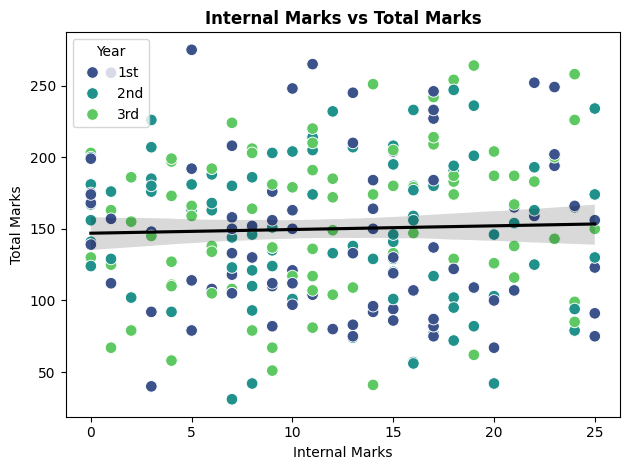

In [ ]:
plt.figure()

sns.scatterplot(
    x="Internal_Marks",
    y="Total",
    data=df,
    hue="Year",
    palette="viridis",
    s=70
)

sns.regplot(
    x="Internal_Marks",
    y="Total",
    data=df,
    scatter=False,
    color="black"
)

plt.title("Internal Marks vs Total Marks", weight='bold')
plt.xlabel("Internal Marks")
plt.ylabel("Total Marks")

plt.tight_layout()
plt.show()